# Outlier Analysis

Note - This is copied from a primitive version, which was not 100% completed as there were were still data issues to address earlier in the pipeline. Once those are resolved, this notebook will be revised.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
scout_car = pd.read_csv('Step 2 - Nulls filled v1.csv')
scout_car

,make_model,Body Type,Price,VAT,KM,Registration (YYYYMM),Horsepower (kW),Type,Previous Owners,Next Inspection (YYYYMM),...,Lane departure warning system,Night view assist,Passenger-side airbag,Power steering,Rear airbag,Side airbag,Tire pressure monitoring system,Traction control,Traffic sign recognition,Xenon headlights
0,Audi A1,Sedans,15770,VAT deductible,56013.0,201601.0,66.0,Used,2,202106.0,...,0,0,1,1,0,1,1,1,0,1
1,Audi A1,Sedans,14500,Price negotiable,80000.0,201703.0,141.0,Used,0,NaN,...,0,0,1,1,0,1,1,1,0,1
2,Audi A1,Sedans,14640,VAT deductible,83450.0,201602.0,85.0,Used,1,NaN,...,0,0,1,1,0,1,1,1,0,0
3,Audi A1,Sedans,14500,VAT deductible,73000.0,201608.0,66.0,Used,1,NaN,...,0,0,1,1,0,1,1,0,0,0
4,Audi A1,Sedans,16790,VAT deductible,16200.0,201605.0,66.0,Used,1,NaN,...,0,0,1,1,0,1,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15914,Renault Espace,Van,39950,VAT deductible,21213.5,201711.0,147.0,New,0,NaN,...,1,0,1,1,1,1,1,1,1,0
15915,Renault Espace,Van,39885,VAT deductible,9900.0,201901.0,165.0,Used,1,202201.0,...,1,0,1,1,0,1,1,1,1,0
15916,Renault Espace,Van,39875,VAT deductible,15.0,201903.0,146.0,Pre-registered,1,NaN,...,1,0,1,1,0,1,0,1,1,0
15917,Renault Espace,Van,39700,VAT deductible,10.0,201906.0,147.0,Pre-registered,0,NaN,...,0,0,1,1,0,1,1,0,1,0


# Ensure all dtypes are what we want.

In [3]:
scout_car.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15919 entries, 0 to 15918
Data columns (total 131 columns):
 #    Column                                 Dtype  
---   ------                                 -----  
 0    make_model                             object 
 1    Body Type                              object 
 2    Price                                  int64  
 3    VAT                                    object 
 4    KM                                     float64
 5    Registration (YYYYMM)                  float64
 6    Horsepower (kW)                        float64
 7    Type                                   object 
 8    Previous Owners                        int64  
 9    Next Inspection (YYYYMM)               float64
 10   Inspection new                         int64  
 11   Warranty (months)                      float64
 12   Make                                   object 
 13   Model                                  object 
 14   First Registration                  

Nothing is an object that shouldn't be. That's a good starting point.

In [4]:
def detect_outliers_iqr(df):
    outlier_info = {}
    for col in df.select_dtypes(include=['number']).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Get outlier indices
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        outlier_info[col] = {
            "num_outliers": len(outliers),
            "pct_outliers": round(len(outliers) / len(df) * 100, 2),
            "outlier_indices": outliers.index.tolist()
        }
    return pd.DataFrame(outlier_info).T


In [5]:
outlier_summary = detect_outliers_iqr(scout_car)
outlier_summary

,num_outliers,pct_outliers,outlier_indices
Price,479,3.01,"[713, 732, 3587, 3589, 3590, 3591, 3592, 3593,..."
KM,847,5.32,"[25, 34, 39, 43, 53, 61, 63, 64, 310, 328, 333..."
Registration (YYYYMM),0,0.0,[]
Horsepower (kW),428,2.69,"[3353, 3587, 3590, 3592, 3593, 3594, 3595, 359..."
Previous Owners,19,0.12,"[679, 972, 1290, 2729, 3269, 6103, 6406, 6669,..."
...,...,...,...
Side airbag,2716,17.06,"[9, 18, 28, 30, 50, 53, 66, 67, 69, 76, 115, 1..."
Tire pressure monitoring system,0,0.0,[]
Traction control,0,0.0,[]
Traffic sign recognition,1976,12.41,"[165, 446, 447, 506, 597, 602, 737, 1280, 1648..."


# Let's have a look at these outliers.

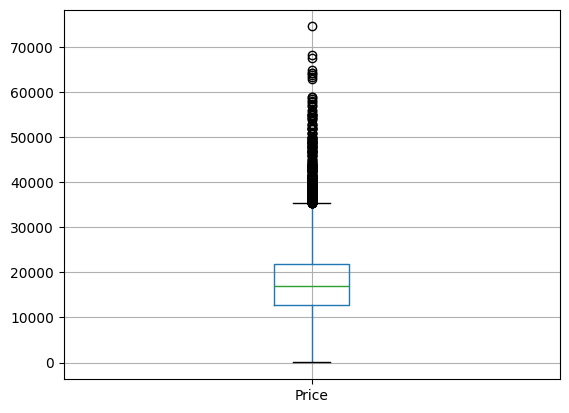

In [6]:
scout_car.boxplot(column='Price')
plt.show()

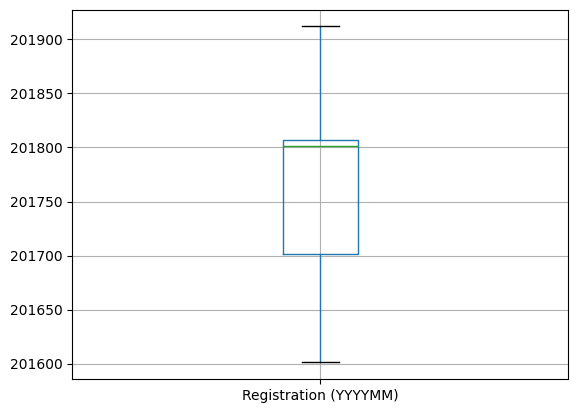

In [7]:
scout_car.boxplot(column='Registration (YYYYMM)')
plt.show()

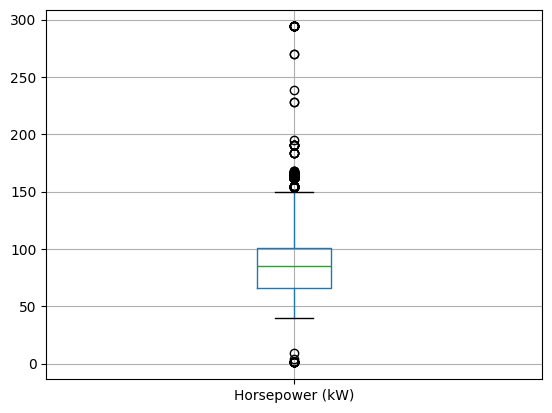

In [8]:
scout_car.boxplot(column='Horsepower (kW)')
plt.show()

Suspiciously low.
# COME BACK TO THIS

In [9]:
scout_car['Type'].value_counts()

Type
Used              11098
New                1650
Pre-registered     1364
Employee's car     1011
Demonstration       796
Name: count, dtype: int64

In [10]:
scout_car['Previous Owners'].value_counts()

Previous Owners
1    8294
0    6828
2     778
3      17
4       2
Name: count, dtype: int64

Might dump this inspection column. Intuitively doesn't seem this would have any bearing. But that can be a decision for later.

In [11]:
scout_car['Next Inspection (YYYYMM)'].value_counts()

Next Inspection (YYYYMM)
202106.0    471
202103.0    210
202105.0    180
202104.0    171
202102.0    168
           ... 
201405.0      1
201604.0      1
195501.0      1
201801.0      1
202211.0      1
Name: count, Length: 77, dtype: int64

In [12]:
scout_car['Inspection new'].value_counts()

Inspection new
0    11987
1     3932
Name: count, dtype: int64

In [13]:
scout_car['Warranty (months)'].value_counts()

Warranty (months)
12.0    11900
16.0     2609
24.0      552
60.0      382
36.0      223
6.0        49
72.0       44
48.0       40
3.0        14
23.0       10
20.0        7
18.0        7
25.0        5
50.0        4
2.0         4
34.0        3
21.0        2
22.0        2
17.0        2
14.0        2
46.0        2
11.0        2
26.0        2
1.0         2
13.0        2
45.0        2
65.0        1
33.0        1
28.0        1
15.0        1
7.0         1
19.0        1
10.0        1
56.0        1
49.0        1
47.0        1
40.0        1
Name: count, dtype: int64

In [14]:
scout_car['First Registration'].value_counts()

First Registration
2018.0    5367
2017.0    4007
2016.0    3674
2019.0    2871
Name: count, dtype: int64

In [15]:
scout_car['Body Color'].value_counts()

Body Color
Black     3957
Grey      3771
White     3525
Silver    1647
Blue      1431
Red        957
Brown      289
Green      154
Beige      108
Yellow      51
Violet      18
Bronze       6
Orange       3
Gold         2
Name: count, dtype: int64

Since there are a lot of uncommon colors, we can combine them all into "other"

In [16]:
scout_car['Body Color'] = scout_car['Body Color'].replace(['Brown', 'Green', 'Beige',  'Yellow', 'Violet', 'Bronze', 'Orange', 'Gold'], 'Other')

In [17]:
scout_car['Paint Type'].value_counts()

Paint Type
Metallic       15549
Uni/basic        364
Perl effect        6
Name: count, dtype: int64

In [18]:
scout_car['Body Color Original'].value_counts()

Body Color Original
Onyx Schwarz                     1808
Brillantschwarz                  1085
Bianco                            890
Mythosschwarz Metallic            760
Grigio                            462
                                 ... 
Nero mito                           1
White & Black                       1
mythosschwarz perl.                 1
BLAU                                1
Perlmutt-Weiß Metallic (Weiß)       1
Name: count, Length: 1926, dtype: int64

'Body Color Original' was here, but was dropped.

Domain knowledge - Should these be changed?

In [21]:
scout_car['# of Doors'].value_counts()

# of Doors
5.0    11787
4.0     3079
3.0      832
2.0      219
1.0        1
7.0        1
Name: count, dtype: int64

In [22]:
scout_car['# of Seats'].value_counts()

# of Seats
5.0    14313
4.0     1125
7.0      362
2.0      116
6.0        2
3.0        1
Name: count, dtype: int64

'Model Code' was here but was dropped.

In [23]:
scout_car['Model Code'].nunique()

232

This is another column that is likely to cause more confusion than it is worth, as it would create over 200 dummy columns. Let's drop it.

In [24]:
scout_car.drop('Model Code', axis=1, inplace=True)

In [25]:
scout_car['Gearing Type'].value_counts()

Gearing Type
Manual            8153
Automatic         7297
Semi-automatic     469
Name: count, dtype: int64

Get back to displacement after refining null filling.

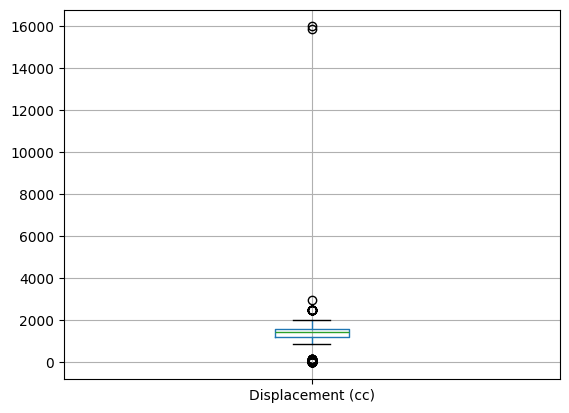

In [26]:
scout_car.boxplot(column='Displacement (cc)')
plt.show()

In [27]:
scout_car['Cylinders'].value_counts()

Cylinders
4.0    12925
3.0     2963
5.0       22
6.0        3
8.0        2
2.0        2
1.0        1
Name: count, dtype: int64

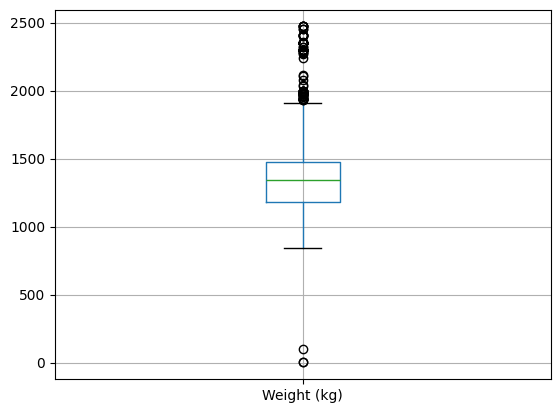

In [28]:
scout_car.boxplot(column='Weight (kg)')
plt.show()

This is strange. A few values are drastically lower than the rest. Let's see them.

In [29]:
scout_car[scout_car['Weight (kg)'] < 500]

,make_model,Body Type,Price,VAT,KM,Registration (YYYYMM),Horsepower (kW),Type,Previous Owners,Next Inspection (YYYYMM),...,Lane departure warning system,Night view assist,Passenger-side airbag,Power steering,Rear airbag,Side airbag,Tire pressure monitoring system,Traction control,Traffic sign recognition,Xenon headlights
1143,Audi A1,Compact,19229,VAT deductible,8263.0,201805.0,70.0,Used,1,201905.0,...,0,0,1,1,0,1,1,1,0,0
8355,Opel Corsa,Compact,12945,VAT deductible,2015.0,201801.0,66.0,Used,1,202101.0,...,0,0,1,1,0,1,1,1,0,0
12779,Opel Insignia,Station wagon,39299,VAT deductible,10.0,201901.0,121.0,New,0,NaN,...,1,0,0,0,0,0,0,0,0,0


We will find the median weight for each make_model and replace the value based on index.

In [30]:
audi_a1_df = scout_car[scout_car['make_model'] == 'Audi A1']
audi_a1_df['Weight (kg)'].median()

np.float64(1180.0)

In [31]:
scout_car.loc[1143, 'Weight (kg)'] = 1180 

In [32]:
opel_corsa_df = scout_car[scout_car['make_model'] == 'Opel Corsa']
opel_corsa_df['Weight (kg)'].median()

np.float64(1163.0)

In [33]:
scout_car.loc[8355, 'Weight (kg)'] = 1163 

In [34]:
open_insignia_df = scout_car[scout_car['make_model'] == 'Opel Insignia']
open_insignia_df['Weight (kg)'].median()

np.float64(1543.0)

In [35]:
scout_car.loc[12779, 'Weight (kg)'] = 1543.0 

In [36]:
# Validate this worked
scout_car[scout_car['Weight (kg)'] < 500]

,make_model,Body Type,Price,VAT,KM,Registration (YYYYMM),Horsepower (kW),Type,Previous Owners,Next Inspection (YYYYMM),...,Lane departure warning system,Night view assist,Passenger-side airbag,Power steering,Rear airbag,Side airbag,Tire pressure monitoring system,Traction control,Traffic sign recognition,Xenon headlights


In [37]:
scout_car['Drive chain'].value_counts()

Drive chain
front    15712
4WD        203
rear         4
Name: count, dtype: int64

Domain knowledge - is this likely? Leave it for now but may change later.

In [38]:
scout_car['Fuel'].value_counts()

Fuel
Diesel (Particulate Filter)                                                                                  4315
Super 95                                                                                                     3338
Gasoline                                                                                                     3175
Diesel                                                                                                       2984
Super 95 / Regular/Benzine 91                                                                                 424
                                                                                                             ... 
Regular/Benzine 91 / Super 95 / Regular/Benzine E10 91                                                          1
Super Plus 98 / Super E10 95                                                                                    1
Regular/Benzine 91 / Super 95 / Regular/Benzine E10 91 / Super E10 95 / Super Plus 

In [39]:
scout_car['Fuel'].nunique()

77

Could 'regular' and 'gasoline' be treated as synonyms?

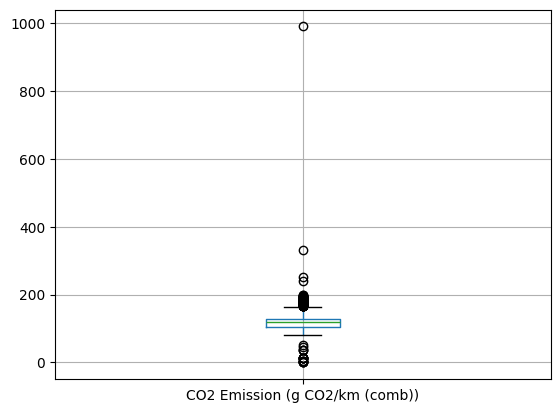

In [40]:
scout_car.boxplot(column='CO2 Emission (g CO2/km (comb))')
plt.show()

One extreme outlier. Let's see it.

In [41]:
scout_car[scout_car['CO2 Emission (g CO2/km (comb))'] > 800]

,make_model,Body Type,Price,VAT,KM,Registration (YYYYMM),Horsepower (kW),Type,Previous Owners,Next Inspection (YYYYMM),...,Lane departure warning system,Night view assist,Passenger-side airbag,Power steering,Rear airbag,Side airbag,Tire pressure monitoring system,Traction control,Traffic sign recognition,Xenon headlights
4556,Audi A3,Sedans,23500,VAT deductible,27815.0,201803.0,81.0,Used,0,NaN,...,0,0,0,1,0,0,0,1,0,1


In [42]:
high_emission_df = scout_car[scout_car['CO2 Emission (g CO2/km (comb))'] > 800]
high_emission_df[['CO2 Emission (g CO2/km (comb))']]

,CO2 Emission (g CO2/km (comb))
4556,990.0


In [43]:
audi_a3_df = scout_car[scout_car['make_model'] == 'Audi A3']
audi_a3_df['CO2 Emission (g CO2/km (comb))'].median()

np.float64(107.0)

In [44]:
scout_car.loc[4556, 'CO2 Emission (g CO2/km (comb))'] = 107 

In [45]:
scout_car[scout_car['CO2 Emission (g CO2/km (comb))'] > 800]

,make_model,Body Type,Price,VAT,KM,Registration (YYYYMM),Horsepower (kW),Type,Previous Owners,Next Inspection (YYYYMM),...,Lane departure warning system,Night view assist,Passenger-side airbag,Power steering,Rear airbag,Side airbag,Tire pressure monitoring system,Traction control,Traffic sign recognition,Xenon headlights


In [46]:
scout_car['Emission Class'].value_counts()

Emission Class
Euro 6          13765
Euro 6d-TEMP     1845
Euro 6c           127
Euro 5             78
Euro 6d            62
Euro 4             42
Name: count, dtype: int64

In [47]:
scout_car['Emission Label'].value_counts()

Emission Label
4 (Green)         15493
1 (No sticker)      381
5 (Blue)              8
3 (Yellow)            2
2 (Red)               1
Name: count, dtype: int64

In [48]:
scout_car['Gears'].value_counts()

Gears
6.0     9361
5.0     4411
7.0     1908
8.0      224
9.0        6
1.0        2
3.0        2
4.0        2
2.0        1
50.0       1
Name: count, dtype: int64

50 gears?

In [49]:
scout_car[scout_car['Gears'] > 49]

,make_model,Body Type,Price,VAT,KM,Registration (YYYYMM),Horsepower (kW),Type,Previous Owners,Next Inspection (YYYYMM),...,Lane departure warning system,Night view assist,Passenger-side airbag,Power steering,Rear airbag,Side airbag,Tire pressure monitoring system,Traction control,Traffic sign recognition,Xenon headlights
14495,Renault Clio,Sedans,10798,VAT deductible,10.0,201901.0,56.0,Pre-registered,1,NaN,...,0,0,1,0,0,1,1,1,0,0


In [50]:
renault_clio_df = scout_car[scout_car['make_model'] == 'Renault Clio']
renault_clio_df['Gears'].median()

np.float64(5.0)

In [51]:
scout_car.loc[14495, 'Gears'] = 5

In [52]:
scout_car[scout_car['Gears'] > 49]

,make_model,Body Type,Price,VAT,KM,Registration (YYYYMM),Horsepower (kW),Type,Previous Owners,Next Inspection (YYYYMM),...,Lane departure warning system,Night view assist,Passenger-side airbag,Power steering,Rear airbag,Side airbag,Tire pressure monitoring system,Traction control,Traffic sign recognition,Xenon headlights


In [53]:
scout_car['Country version'].value_counts()

Country version
Germany           12810
Italy              1038
European Union      507
Netherlands         464
Spain               325
Belgium             314
Austria             208
Czech Republic       52
Poland               49
France               38
Denmark              33
Japan                33
Hungary              28
Slovakia              4
Croatia               4
Sweden                3
Romania               2
Bulgaria              2
Luxembourg            1
Switzerland           1
Slovenia              1
Egypt                 1
Serbia                1
Name: count, dtype: int64

Several uncommon countries. I will use Hungary as our lower boundary, as Slovakia - Hungary is proportionally a bigger jump than Czech - Austria.

In [54]:
# More primitive version, hard coded
#scout_car['Country version'] = scout_car['Country version'].replace(['Slovakia', 'Croatia', 'Sweden',  'Romania', 'Bulgaria', 'Luxembourg', 'Switzerland', 'Slovenia', 'Egypt', 'Serbia'], 'Other')

In [55]:
# Find values with count < 28
counts = scout_car['Country version'].value_counts()

# Replace those with 'Other'
scout_car['Country version'] = scout_car['Country version'].where(
    scout_car['Country version'].map(counts) >= 28,
    'Other'
)

In [57]:
scout_car['Upholstery Material'].value_counts()

Upholstery Material
Cloth           11817
Part leather     1499
Full leather     1335
Black             491
Other             368
Grey              273
Velour             60
alcantara          57
Brown              12
Beige               3
Blue                2
White               2
Name: count, dtype: int64

Some of these values list a color as the material. It's possible this was a data cleaning mistake, but impossible to verify without checking every row manually. For now I will simply drop these rows.

In [61]:
wrong_materials = ['Black', 'Grey', 'Brown', 'Beige', 'Blue', 'White']
scout_car = scout_car[~scout_car['Upholstery Material'].isin(wrong_materials)]

In [62]:
scout_car['Upholstery Material'].value_counts()

Upholstery Material
Cloth           11817
Part leather     1499
Full leather     1335
Other             368
Velour             60
alcantara          57
Name: count, dtype: int64

In [58]:
scout_car['Upholstery Color'].value_counts()

Upholstery Color
Black     13555
Grey       1119
Other       960
Brown       195
Beige        51
Blue         14
White        11
Red           9
Yellow        4
Orange        1
Name: count, dtype: int64

In [63]:
# Find values with count < 28
counts = scout_car['Upholstery Color'].value_counts()

# Replace those with 'Other'
scout_car['Upholstery Color'] = scout_car['Upholstery Color'].where(
    scout_car['Upholstery Color'].map(counts) >= 195,
    'Other'
)

/var/folders/cf/4zrkk0lx1nbdx9tpklpk4jc00000gn/T/ipykernel_24718/275237872.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scout_car['Upholstery Color'] = scout_car['Upholstery Color'].where(


In [65]:
scout_car['Upholstery Color'].value_counts()

Upholstery Color
Black    12772
Grey      1119
Other     1050
Brown      195
Name: count, dtype: int64

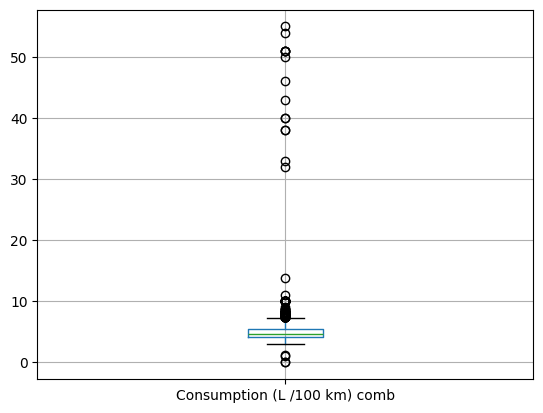

In [67]:
scout_car.boxplot(column='Consumption (L /100 km) comb')
plt.show()

There are some outliers here, but all are relatively close to some other points. I will assume accuracy in this case and leave it alone.

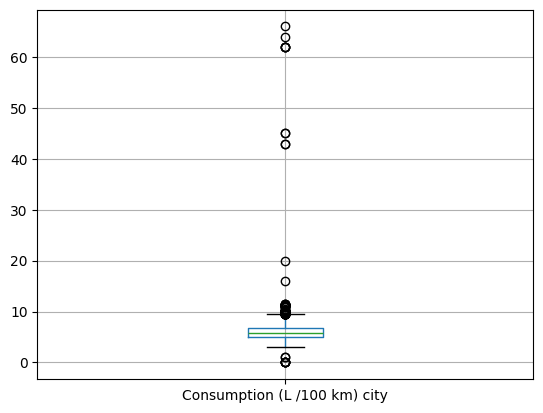

In [68]:
scout_car.boxplot(column='Consumption (L /100 km) city')
plt.show()

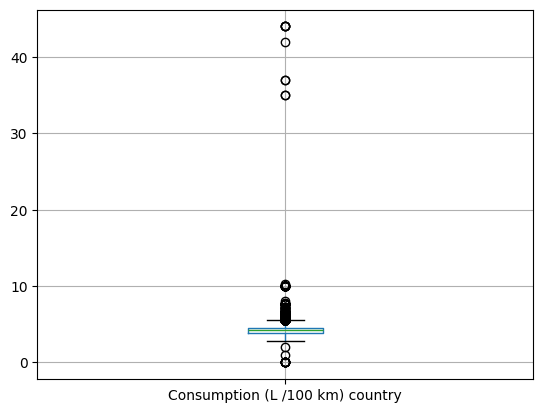

In [69]:
scout_car.boxplot(column='Consumption (L /100 km) country')
plt.show()

These two may need more work. Come back to it.

# This is the point where we reach the safety columns.

# Get Dummies Here?

In [70]:
# Identify non-numeric columns
non_numerics = scout_car.select_dtypes(exclude=['number']).columns

# Apply get_dummies to non-numeric columns
dummy_df = pd.get_dummies(scout_car[non_numerics])

# Convert bools to int
dummy_df = pd.get_dummies(scout_car[non_numerics])
dummy_df = dummy_df.astype(int)

# Select numeric columns from the original DataFrame
numerics_df = scout_car.select_dtypes(include=['number'])

scout_car_with_dummies = pd.concat([numerics_df, dummy_df], axis=1)

In [1]:
scout_car_with_dummies.isnull().sum()

NameError: name 'scout_car_with_dummies' is not defined

In [ ]:
scout_car_with_dummies